# Visual GR validation against SIM5

This optional notebook generates the microcaustics Kerr redshift and disk-brightness maps live, then compares them with an independently generated SIM5 transfer. Set `MICROCAUSTICS_SIM5_DIR` to a case directory containing `sim5_raw.npz`. SIM5 remains an optional validation input and is never required by the package runtime.


## Generate the microcaustics GR map

The validation uses the Q2237 image-B disk parameters and the endpoint-sampled observer screen used by the independent SIM5 bridge. The package trace below is calculated now. No saved microcaustics transfer or comparison array is loaded.


In [1]:
import os
from pathlib import Path
import numpy as np
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp
from microcaustics.relativity import novikov_thorne_flux_factor

plt.rcParams.update(mcp.publication_style())
OUTPUT_DIRECTORY = Path("sim5_gr_validation_output")
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
capabilities = mc.RuntimeCapabilities.detect()
device = torch.device("cuda" if capabilities.cuda_available else "cpu")
dtype = torch.float32
resolution = 1024 if capabilities.cuda_available else 256
spin = 0.74
inclination_deg = 10.0
screen_half_size_rg = 55.0
disk_outer_rg = 50.0

# The external validation contract samples both endpoints of the screen.
coordinate = torch.linspace(
    -screen_half_size_rg, screen_half_size_rg, resolution,
    device=device, dtype=dtype,
)
screen_y, screen_x = torch.meshgrid(coordinate, coordinate, indexing="ij")
screen = mc.ObserverScreen(
    screen_x,
    screen_y,
    torch.ones_like(screen_x),
    metadata={"sampling": "SIM5 validation endpoints"},
)
trace = mc.trace_primary_equatorial(
    screen,
    spin=spin,
    inclination_deg=inclination_deg,
    disk_outer_rg=disk_outer_rg,
    compile_solver=capabilities.cuda_available,
)
live_g = trace.transfer.gfactor.detach().cpu().numpy()
live_radius = trace.transfer.radius_rg.detach().cpu().numpy()
live_hit = trace.transfer.hit.detach().cpu().numpy()
print("Generated live microcaustics transfer:", live_g.shape)
print("Execution:", trace.transfer.metadata["execution"])
print("Hit fraction:", float(live_hit.mean()))


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\relativity\primary.py:223: CompilationWarning: Compilation event 1: preparing a new torch.compile specialization for primary Kerr ray tracing on cuda:0 (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  calculation, execution = _primary_calculation(


Generated live microcaustics transfer: (1024, 1024)
Execution: torch.compile(reduce-overhead, cache=miss)
Hit fraction: 0.6599464416503906


## Redshift map

The frequency-shift factor is $g=\nu_{\rm obs}/\nu_{\rm em}$. Values below one are net redshifts and values above one are net blueshifts. White pixels do not reach the emitting disk on the primary image.


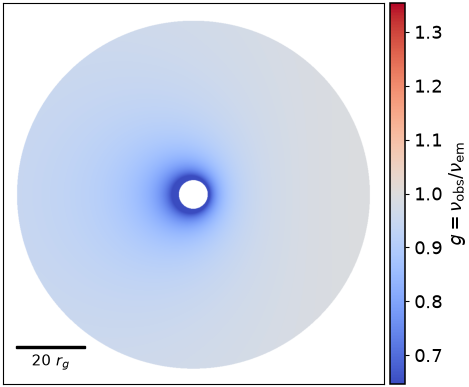

In [2]:
figure, axis = plt.subplots(figsize=(5.0, 4.2))
g_display = np.where(live_hit, live_g, np.nan)
g_delta = max(float(np.nanpercentile(np.abs(g_display - 1.0), 99.5)), 0.05)
artist = axis.imshow(
    g_display,
    origin="lower",
    extent=(-screen_half_size_rg, screen_half_size_rg) * 2,
    cmap="coolwarm",
    vmin=1.0 - g_delta,
    vmax=1.0 + g_delta,
)
mcp.add_scale_bar(axis, 20.0, label=r"20 $r_g$", color="black")
mcp.hide_image_axes(axis)
mcp.panel_colorbar(figure, axis, artist, label=r"$g=\nu_{\rm obs}/\nu_{\rm em}$")
figure.tight_layout()
figure.savefig(OUTPUT_DIRECTORY / "live_gr_redshift_map.png", dpi=220, bbox_inches="tight")


## Pixel-level comparison with SIM5

Only the SIM5 arrays are read from disk. The shared Page--Thorne brightness proxy and both residual maps are calculated from the live microcaustics trace above. The comparison mask retains pixels reached by both primary-image solutions.


SIM5 transfer: configured


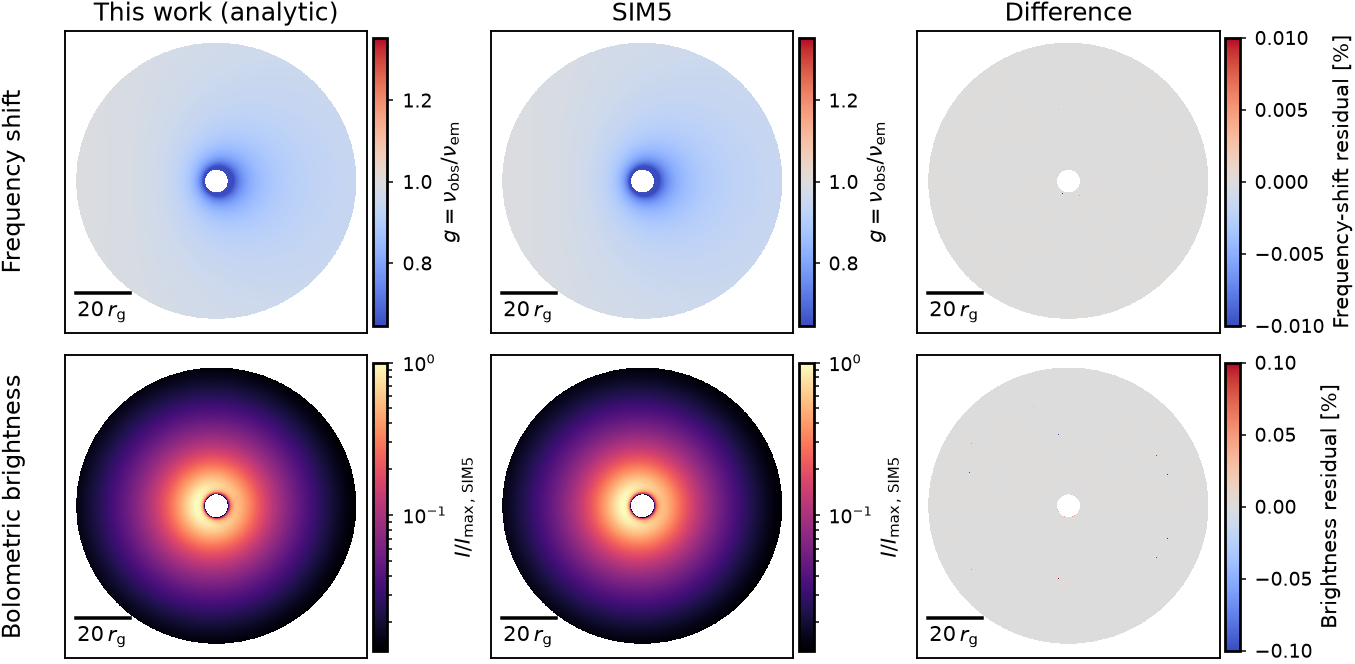

Shared hit coverage: 1.0
Median |g residual|: 3.8032486528738065e-08
RMS symmetric brightness residual: 4.399720404814165e-05


In [3]:
def workspace_root():
    candidates = (Path(mcp.__file__).resolve().parents[4], Path.cwd(), *Path.cwd().parents)
    return next(
        (path for path in candidates if (path / "microcaustics_package").is_dir() and (path / "output").is_dir()),
        Path.cwd(),
    )

def symmetric_fractional(first, second, mask):
    result = np.full(first.shape, np.nan, dtype=np.float64)
    denominator = np.abs(first) + np.abs(second)
    valid = mask & np.isfinite(first) & np.isfinite(second) & (denominator > 0.0)
    result[valid] = 2.0 * (first[valid] - second[valid]) / denominator[valid]
    return result

def ordinary_fractional(first, second, mask):
    result = np.full(first.shape, np.nan, dtype=np.float64)
    valid = mask & np.isfinite(first) & np.isfinite(second) & (second != 0.0)
    result[valid] = (first[valid] - second[valid]) / second[valid]
    return result

def boundary_band(mask):
    padded = np.pad(mask, 1, mode="edge")
    band = np.zeros_like(mask, dtype=bool)
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            band |= padded[1 + dy:1 + dy + mask.shape[0], 1 + dx:1 + dx + mask.shape[1]] != mask
    return band

default_case = workspace_root() / "output/final_paper_run_production_v4/sim5/Q2237_0305"
case_dir = Path(os.environ.get("MICROCAUSTICS_SIM5_DIR", default_case))
sim5_path = case_dir / "sim5_raw.npz"
print("SIM5 transfer:", "configured" if sim5_path.is_file() else "not configured")

if sim5_path.is_file():
    with np.load(sim5_path, allow_pickle=False) as saved:
        sim5 = {name: np.asarray(saved[name]) for name in saved.files}
    if sim5["gfactor"].shape != live_g.shape:
        raise ValueError("SIM5 and live microcaustics screens must have the same shape")
    sim5_hit = np.asarray(sim5["hit"], dtype=bool)
    common = live_hit & sim5_hit
    live_flux = novikov_thorne_flux_factor(
        torch.as_tensor(live_radius, dtype=torch.float64), spin
    ).numpy()
    sim5_flux = novikov_thorne_flux_factor(
        torch.as_tensor(sim5["radius"], dtype=torch.float64), spin
    ).numpy()
    live_intensity = np.where(live_hit, live_flux * live_g.astype(np.float64) ** 4, 0.0)
    sim5_intensity = np.where(sim5_hit, sim5_flux * sim5["gfactor"].astype(np.float64) ** 4, 0.0)
    g_residual = ordinary_fractional(live_g, sim5["gfactor"], common)
    intensity_residual = symmetric_fractional(live_intensity, sim5_intensity, common)

    # Feed the unchanged paper renderer with products generated in this cell.
    live_case = OUTPUT_DIRECTORY / "live_case"
    live_case.mkdir(exist_ok=True)
    np.savez_compressed(
        live_case / "pytorch_analytic_raw.npz",
        screen_x=screen_x.detach().cpu().numpy(),
        screen_y=screen_y.detach().cpu().numpy(),
        gfactor=live_g,
        radius=live_radius,
        hit=live_hit,
    )
    np.savez_compressed(live_case / "sim5_raw.npz", **sim5)
    np.savez_compressed(
        live_case / "comparison_data.npz",
        screen_x=screen_x.detach().cpu().numpy(),
        screen_y=screen_y.detach().cpu().numpy(),
        intensity_pytorch_analytic=live_intensity,
        intensity_sim5=sim5_intensity,
        gfactor_fractional=g_residual,
        intensity_symmetric_fractional=intensity_residual,
        comparison_mask=common,
        boundary_band=boundary_band(live_hit) | boundary_band(sim5_hit),
    )
    figure_path = mcp.render_paper_sim5_validation(live_case, OUTPUT_DIRECTORY)
    from IPython.display import Image, display
    display(Image(filename=str(figure_path)))
    print("Shared hit coverage:", float(common.sum() / (live_hit | sim5_hit).sum()))
    print("Median |g residual|:", float(np.nanmedian(np.abs(g_residual))))
    print("RMS symmetric brightness residual:", float(np.sqrt(np.nanmean(intensity_residual**2))))
else:
    print("Set MICROCAUSTICS_SIM5_DIR to add the independent SIM5 comparison.")


The standalone redshift map is always generated. The SIM5 comparison is added only when its external transfer is available. Runtime comparisons should state whether first-call compilation is included.
